In [1]:
# Imports and Load Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay
)

df = pd.read_csv("heart_cleaned.csv")
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fbs,restecg,max_heart_rate,exercise_induced_angina,st_depression,slope,num_major_vessels,thalassemia,heart_disease
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [2]:
# Set up

target = "heart_disease"

numeric_cols = ["age", "resting_blood_pressure", "cholesterol", "max_heart_rate", "st_depression"]
categorical_cols = [c for c in df.columns if c not in numeric_cols + [target]]

print(df.shape)
print(df[target].value_counts())
print(df.isna().sum())

(302, 14)
heart_disease
1    164
0    138
Name: count, dtype: int64
age                        0
sex                        0
chest_pain_type            0
resting_blood_pressure     0
cholesterol                0
fbs                        0
restecg                    0
max_heart_rate             0
exercise_induced_angina    0
st_depression              0
slope                      0
num_major_vessels          0
thalassemia                0
heart_disease              0
dtype: int64


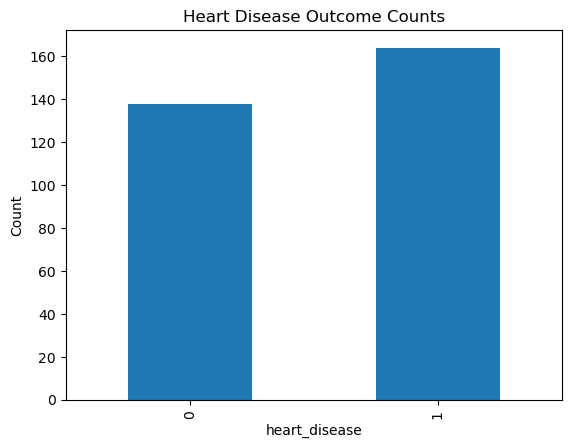

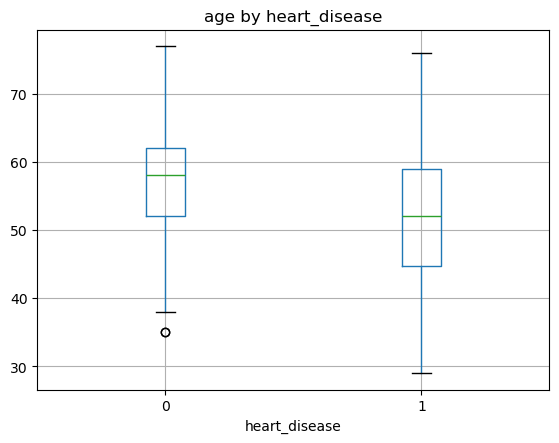

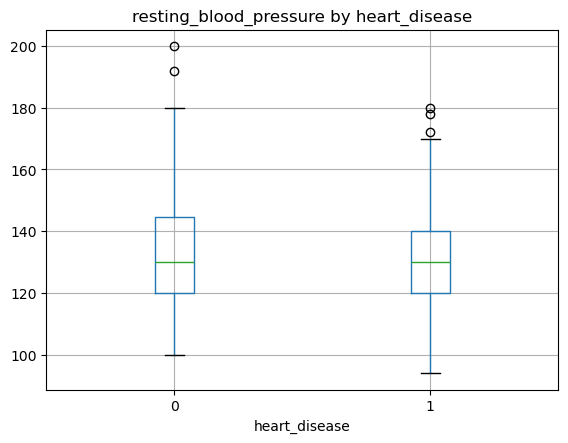

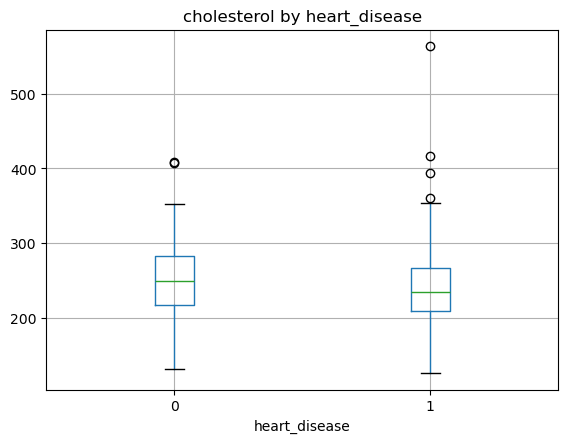

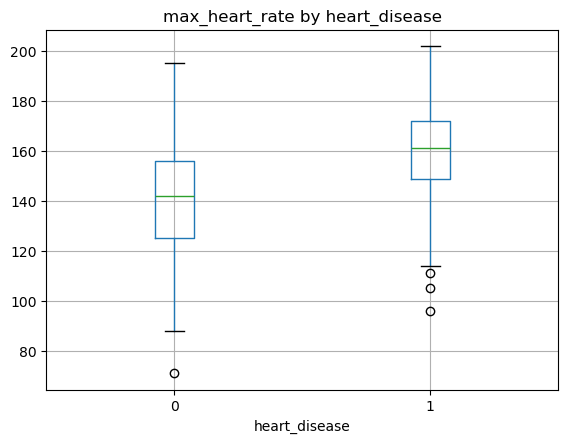

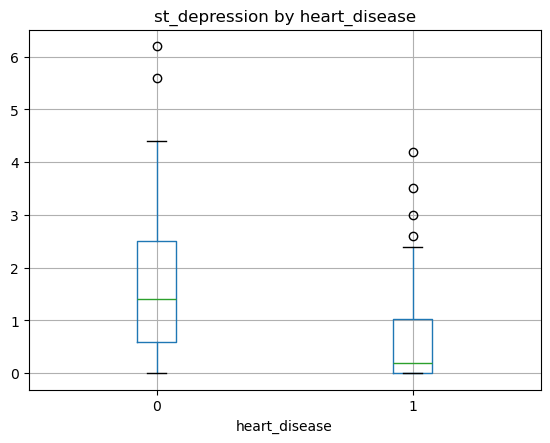

In [4]:
# Simple Visualizations

df[target].value_counts().sort_index().plot(kind="bar")
plt.title("Heart Disease Outcome Counts")
plt.xlabel("heart_disease")
plt.ylabel("Count")
plt.show()

# Numeric boxplots by outcome
for col in numeric_cols:
    df.boxplot(column=col, by=target)
    plt.title(f"{col} by {target}")
    plt.suptitle("")
    plt.show()


In [5]:
# Inferential Tests for Numeric Variables

numeric_results = []

g0 = df[df[target] == 0]
g1 = df[df[target] == 1]

for col in numeric_cols:
    x0 = g0[col].dropna()
    x1 = g1[col].dropna()

    # Welch two-sample t-test
    t_stat, p_val = stats.ttest_ind(x1, x0, equal_var=False)

    mean_diff = x1.mean() - x0.mean()
    se = np.sqrt(x1.var(ddof=1)/len(x1) + x0.var(ddof=1)/len(x0))
    ci_low = mean_diff - 1.96 * se
    ci_high = mean_diff + 1.96 * se

    numeric_results.append({
        "variable": col,
        "mean_group1": x1.mean(),
        "mean_group0": x0.mean(),
        "mean_diff_1_minus_0": mean_diff,
        "p_value": p_val,
        "ci_low": ci_low,
        "ci_high": ci_high
    })

numeric_results = pd.DataFrame(numeric_results).sort_values("p_value")
numeric_results

,variable,mean_group1,mean_group0,mean_diff_1_minus_0,p_value,ci_low,ci_high
3,max_heart_rate,158.378049,139.101449,19.276600,6.904576e-14,14.496309,24.056890
4,st_depression,0.586585,1.585507,-0.998922,1.379412e-13,-1.246682,-0.751162
0,age,52.585366,56.601449,-4.016083,8.177364e-05,-5.986905,-2.045262
1,resting_blood_pressure,129.250000,134.398551,-5.148551,1.199012e-02,-9.138144,-1.158958
2,cholesterol,242.640244,251.086957,-8.446713,1.552756e-01,-20.066606,3.173181


In [ ]:
# Chi-Square Tests for Categorical Variables

cat_results = []

for col in categorical_cols:
    table = pd.crosstab(df[col], df[target])
    chi2, p_val, dof, expected = stats.chi2_contingency(table)

    cat_results.append({
        "variable": col,
        "chi2": chi2,
        "dof": dof,
        "p_value": p_val
    })

cat_results = pd.DataFrame(cat_results).sort_values("p_value")
cat_results

,variable,chi2,dof,p_value
7,thalassemia,84.610318,3,3.146295e-18
1,chest_pain_type,80.978762,3,1.892684e-17
6,num_major_vessels,73.689846,4,3.771038e-15
4,exercise_induced_angina,55.456203,1,9.556466e-14
5,slope,46.889477,2,6.577783e-11
0,sex,23.083879,1,1.550855e-06
3,restecg,9.729682,2,7.713053e-03
2,fbs,0.092408,1,7.611375e-01


In [ ]:
# Logistic Regression with Statsmodels
# Treat categorical vars as categories for statsmodels formula
df_sm = df.copy()
for c in categorical_cols:
    df_sm[c] = df_sm[c].astype("category")

formula = """
heart_disease ~ age + resting_blood_pressure + cholesterol + max_heart_rate + st_depression
+ C(sex) + C(chest_pain_type) + C(fbs) + C(restecg) + C(exercise_induced_angina)
+ C(slope) + C(num_major_vessels) + C(thalassemia)
"""

logit_model = smf.logit(formula=formula, data=df_sm).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.297385
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:          heart_disease   No. Observations:                  302
Model:                          Logit   Df Residuals:                      279
Method:                           MLE   Df Model:                           22
Date:                Tue, 10 Mar 2026   Pseudo R-squ.:                  0.5687
Time:                        12:55:17   Log-Likelihood:                -89.810
converged:                       True   LL-Null:                       -208.21
Covariance Type:            nonrobust   LLR p-value:                 6.186e-38
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                           0.1798      3.704      0.049  

In [9]:
reduced_formula = "heart_disease ~ age + resting_blood_pressure + cholesterol + max_heart_rate + st_depression"
reduced_model = smf.logit(formula=reduced_formula, data=df_sm).fit()

lr_stat = 2 * (logit_model.llf - reduced_model.llf)
df_diff = logit_model.df_model - reduced_model.df_model
lr_p = stats.chi2.sf(lr_stat, df_diff)

print("LR statistic:", lr_stat)
print("df difference:", df_diff)
print("p-value:", lr_p)

Optimization terminated successfully.
         Current function value: 0.532765
         Iterations 6
LR statistic: 142.1696368093556
df difference: 17.0
p-value: 8.261013074649436e-22


In [11]:
# Logistic Regression, Decision Tree, Random Forest 

X = df.drop(columns=target)
y = df[target]

numeric_features = numeric_cols
categorical_features = categorical_cols

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

models = {
    "logistic_regression": LogisticRegression(max_iter=5000),
    "decision_tree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "random_forest": RandomForestClassifier(n_estimators=300, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
for name, model in models.items():
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipe, X, y, cv=cv,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
    )

    results.append({
        "model": name,
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
        "roc_auc": scores["test_roc_auc"].mean()
    })

model_results = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
model_results

,model,accuracy,precision,recall,f1,roc_auc
0,logistic_regression,0.864044,0.861773,0.908902,0.880901,0.916059
2,random_forest,0.827541,0.835321,0.866288,0.847099,0.909661
1,decision_tree,0.777760,0.776054,0.835417,0.803654,0.782759


Logistic Regression
Accuracy: 0.8524590163934426
Precision: 0.8529411764705882
Recall: 0.8787878787878788
F1: 0.8656716417910447
ROC-AUC: 0.8971861471861471



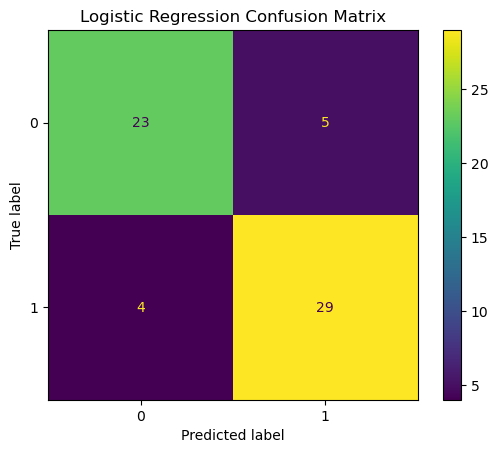

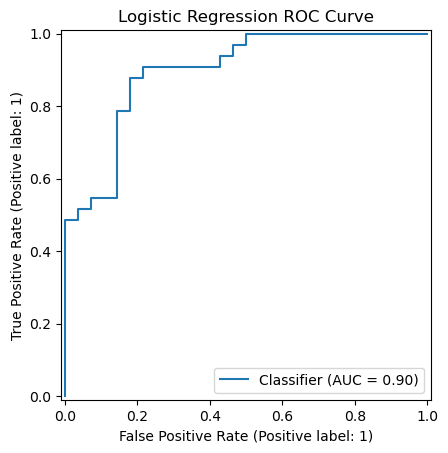

Random Forest
Accuracy: 0.7868852459016393
Precision: 0.7631578947368421
Recall: 0.8787878787878788
F1: 0.8169014084507042
ROC-AUC: 0.9053030303030303



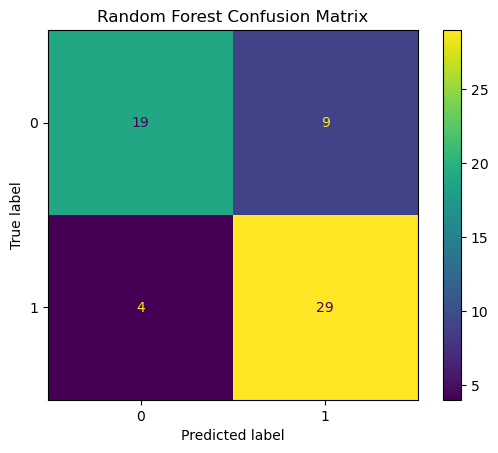

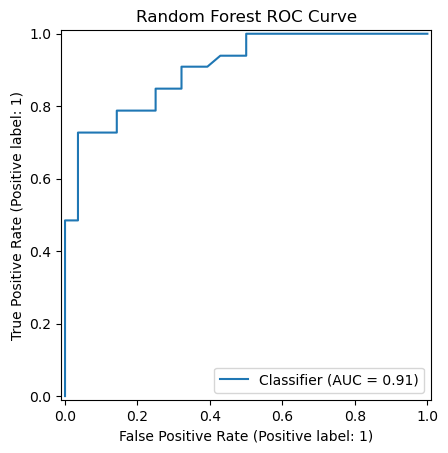

In [12]:
# Train/Test for Best Models

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

log_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=5000))
])

rf_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(n_estimators=300, random_state=42))
])

log_pipe.fit(X_train, y_train)
rf_pipe.fit(X_train, y_train)

for name, pipe in [("Logistic Regression", log_pipe), ("Random Forest", rf_pipe)]:
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    print(name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print()

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.title(f"{name} ROC Curve")
    plt.show()

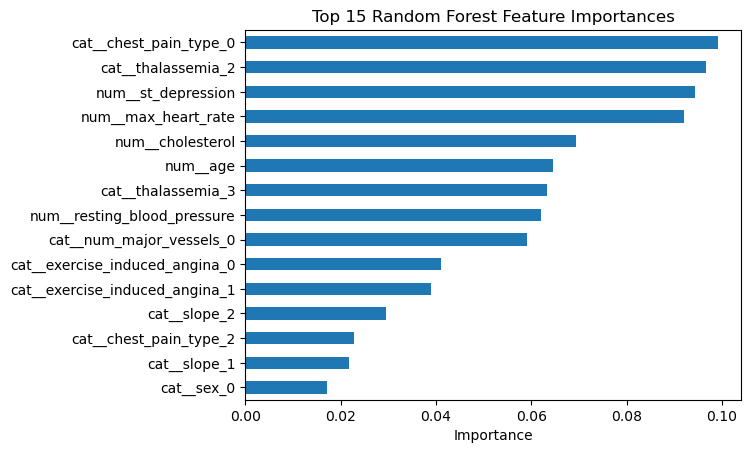

In [ ]:
# Top 15 Random Forest Feature Importances

rf_model = rf_pipe.named_steps["model"]
feature_names = rf_pipe.named_steps["prep"].get_feature_names_out()
importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)

importances.sort_values().plot(kind="barh")
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.show()

In [ ]:
# Minimal Results output

print("Top numeric variables by p-value:")
print(numeric_results[["variable", "p_value"]].head(), "\n")

print("Top categorical variables by p-value:")
print(cat_results[["variable", "p_value"]].head(), "\n")


print("Model comparison:")
print(model_results)

Top numeric variables by p-value:
                 variable       p_value
3          max_heart_rate  6.904576e-14
4           st_depression  1.379412e-13
0                     age  8.177364e-05
1  resting_blood_pressure  1.199012e-02
2             cholesterol  1.552756e-01 

Top categorical variables by p-value:
                  variable       p_value
7              thalassemia  3.146295e-18
1          chest_pain_type  1.892684e-17
6        num_major_vessels  3.771038e-15
4  exercise_induced_angina  9.556466e-14
5                    slope  6.577783e-11 

Top logistic regression effects:
                                 odds_ratio   p_value
C(num_major_vessels)[T.1]          0.096154  0.000009
C(num_major_vessels)[T.2]          0.030732  0.000018
C(chest_pain_type)[T.2]            7.402051  0.000157
C(chest_pain_type)[T.3]           11.203634  0.000781
C(sex)[T.1]                        0.155401  0.001107
C(num_major_vessels)[T.3]          0.105693  0.016521
resting_blood_pressure     